# 03 · Comparing cultivars and maturity groups

Compare soybean grain yield and maturity across seven generic maturity groups while keeping Gainesville treatment 1's management fixed.

## You will learn

- Find crop names and generic soybean maturity-group cultivar codes.
- Swap cultivars through experiment-data scenarios while keeping management fixed.
- Compare grain yield and maturity in a table and an inline bar plot.

In [1]:
LESSON = "03_cultivars"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load tools for tables and inline plots.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Select the copied stock inputs in `runs/` so every execution starts fresh.

In [4]:
# Select the copied FileX, weather and soil files.
inputs = {
    "filex": RUNS / "UFGA7901.SBX",
    "weather": RUNS / "UFGA7901.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
print("Inputs:", ", ".join(inputs[key].relative_to(HERE).as_posix()
                          for key in ("filex", "weather", "soil")))

Inputs: runs/UFGA7901.SBX, runs/UFGA7901.WTH, runs/SOIL.SOL


List the template crops available in your installed DSSAT and find soybean (`SB`).

In [5]:
# List available template crops and their cultivar counts.
crops = dl.to_dataframe(dl.list_crops(executable=dssat))
crops

,crop,code,model,cultivars
0,maize,MZ,MZCER048,167
1,wheat,WH,CSCER048,11
2,rice,RI,RICER048,57
3,soybean,SB,CRGRO048,56
4,potato,PT,PTSUB048,20
5,sorghum,SG,SGCER048,57
6,pearl millet,ML,MLCER048,56
7,barley,BA,CSCER048,6
8,peanut,PN,CRGRO048,40
9,dry bean,BN,CRGRO048,32


List soybean cultivars and keep only codes `990001` through `990013`, the generic maturity groups in stock `SBGRO048.CUL`.

In [6]:
# Filter the cultivar list to the thirteen generic maturity groups.
cultivars = dl.list_cultivars("SB", executable=dssat)
generic = [row for row in cultivars if "990001" <= row["code"] <= "990013"]
dl.to_dataframe(generic)

,code,name
0,990011,M GROUP 000
1,990012,M GROUP 00
2,990013,M GROUP 0
3,990001,M GROUP 1
4,990002,M GROUP 2
5,990003,M GROUP 3
6,990004,M GROUP 4
7,990005,M GROUP 5
8,990006,M GROUP 6
9,990007,M GROUP 7


🌱 Crop idea  
Soybean is a short-day crop: day length affects reproductive development, and maturity groups describe differences in adaptation.
The generic cultivars differ in several coefficients, so a group comparison does not isolate photoperiod alone.

Preview the stock treatment, cultivar and planting details that the scenarios will inherit.

In [7]:
# Preview the stock treatment, cultivar and planting sections.
lines = inputs["filex"].read_text(encoding="latin-1").splitlines()
for section in ("TREATMENTS", "CULTIVARS", "PLANTING DETAILS"):
    start = next(i for i, line in enumerate(lines) if line.startswith("*" + section))
    end = next(i for i in range(start + 1, len(lines)) if lines[i].startswith("*"))
    print("\n".join(line for line in lines[start:end] if line and not line.startswith("!")))

*TREATMENTS                        -------------FACTOR LEVELS------------
@N R O C TNAME.................... CU FL SA IC MP MI MF MR MC MT ME MH SM
 1 1 0 0 79 IRRIG. BRAGG            1  1  0  1  1  1  0  1  0  0  0  0  1
 2 1 0 0 79 RAINFED BRAGG           1  1  0  1  1  0  0  1  0  0  0  0  2
*CULTIVARS
@C CR INGENO CNAME
 1 SB IB0001 BRAGG
*PLANTING DETAILS
@P PDATE EDATE  PPOP  PPOE  PLME  PLDS  PLRS  PLRD  PLDP  PLWT  PAGE  PENV  PLPH  SPRL                        PLNAME
 1 79170   -99    47    47     S     R    76     0     4   -99   -99   -99   -99   -99                        -99


🌱 Crop idea  
Treatment 1 is irrigated Bragg (`IB0001`), planted on 19 June 1979 at 47 plants/m² in 76 cm rows, 4 cm deep.
We retain its irrigation, initial conditions, residues and controls, including water and nitrogen simulation; irrigation does not guarantee zero water stress.

Choose seven groups and build scenarios that replace only treatment 1's cultivar.

In [8]:
# Build cultivar-only scenarios and show their labels and codes.
cultivar_codes = ["990001", "990003", "990005", "990006", "990007", "990008", "990010"]
scenarios = {}
choices = []
for row in generic:
    if row["code"] in cultivar_codes:
        label = "MG " + row["name"].split()[-1]
        scenarios[label] = {"management": {"treatments": {
            1: {"cultivar": {"crop": "SB", "code": row["code"]}}
        }}}
        choices.append({"Maturity group": label, "Cultivar code": row["code"]})
dl.to_dataframe(choices)

,Maturity group,Cultivar code
0,MG 1,990001
1,MG 3,990003
2,MG 5,990005
3,MG 6,990006
4,MG 7,990007
5,MG 8,990008
6,MG 10,990010


🐍 Python idea  
A dictionary pairs a name with a value; each scenario's `management` holds experiment data for treatment `1`.
Omitted experiment sections keep their FileX levels; `list_cultivars("SB")` and `"crop": "SB"` use the same DSSAT crop code; the name `"soybean"` also works for listing.

Run treatment 1 for the base Bragg cultivar and seven groups, then compare `HWAM` (kg/ha) and `MDAT` (maturity date).

In [9]:
# Run the cultivar scenarios and show their Summary results.
results = dl.run_treatments(**inputs, treatments=[1], scenarios=scenarios, directory=RUNS)
summary = dl.to_dataframe(dl.combine_summaries(results))
summary[["scenario", "TRNO", "PDAT", "HWAM", "MDAT"]]

,scenario,TRNO,PDAT,HWAM,MDAT
0,base,1,1979-06-19,3114,1979-10-12
1,MG 1,1,1979-06-19,1763,1979-08-28
2,MG 3,1,1979-06-19,2392,1979-09-08
3,MG 5,1,1979-06-19,2912,1979-09-24
4,MG 6,1,1979-06-19,3154,1979-10-03
5,MG 7,1,1979-06-19,3114,1979-10-13
6,MG 8,1,1979-06-19,3004,1979-10-24
7,MG 10,1,1979-06-19,3338,1979-11-06


Exclude the extra `base` row, which is Bragg rather than a generic group, and plot grain yield for the seven groups.

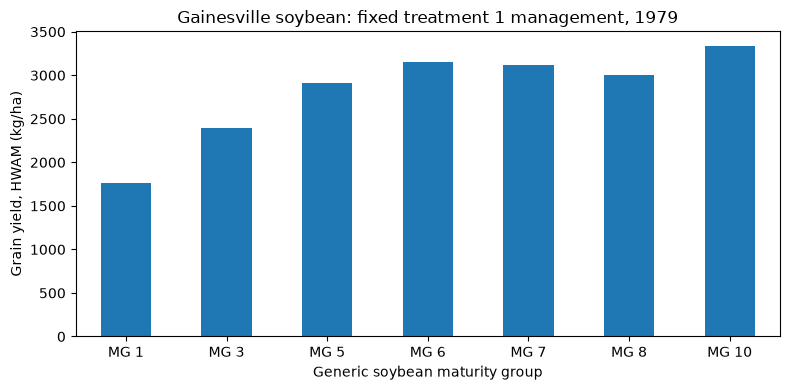

In [10]:
# Plot grain yield for the seven labelled maturity groups.
comparison = summary.loc[summary["scenario"] != "base", ["scenario", "HWAM", "MDAT"]].copy()
ax = comparison.plot.bar(x="scenario", y="HWAM", legend=False, rot=0, figsize=(8, 4))
ax.set(xlabel="Generic soybean maturity group", ylabel="Grain yield, HWAM (kg/ha)",
       title="Gainesville soybean: fixed treatment 1 management, 1979")
plt.tight_layout()
plt.show()

🌱 Crop idea  
MG 10 has the largest shown yield (3,338 kg/ha) and latest maturity (6 November), but yield falls from MG 6 to MG 8 even as maturity gets later.
These are simulated generic cultivars in one season, so this comparison is not a recommendation for local varieties.

## Your turn

Compare a different set of generic cultivars using the same stock treatment.

Hint: edit `cultivar_codes` at the top of this cell using codes from the generic cultivar table, then run this cell.

In [11]:
# Rebuild the cultivar comparison and show its results.
cultivar_codes = ["990002", "990004", "990006", "990008", "990010"]
exercise_inputs = {
    "filex": RUNS / "UFGA7901.SBX",
    "weather": RUNS / "UFGA7901.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
exercise_cultivars = dl.list_cultivars("SB", executable=dssat)
exercise_scenarios = {}
for row in exercise_cultivars:
    if "990001" <= row["code"] <= "990013" and row["code"] in cultivar_codes:
        label = "MG " + row["name"].split()[-1]
        exercise_scenarios[label] = {"management": {"treatments": {
            1: {"cultivar": {"crop": "SB", "code": row["code"]}}
        }}}
exercise_results = dl.run_treatments(**exercise_inputs, treatments=[1], scenarios=exercise_scenarios, directory=RUNS)
exercise_summary = dl.to_dataframe(dl.combine_summaries(exercise_results))
exercise_summary[["scenario", "TRNO", "PDAT", "HWAM", "MDAT"]]

,scenario,TRNO,PDAT,HWAM,MDAT
0,base,1,1979-06-19,3114,1979-10-12
1,MG 2,1,1979-06-19,2011,1979-09-01
2,MG 4,1,1979-06-19,2750,1979-09-16
3,MG 6,1,1979-06-19,3154,1979-10-03
4,MG 8,1,1979-06-19,3004,1979-10-24
5,MG 10,1,1979-06-19,3338,1979-11-06


## Recap

- `list_crops()` and `list_cultivars("SB")` identify available crop names and cultivar codes.
- Cultivar-only experiment data keeps the stock treatment's management fixed, and scenarios include a `base` run.
- `HWAM` compares grain yield in kg/ha; `MDAT` shows when each cultivar reaches maturity.

Next: [04 · Your own weather](../04_own_weather/lesson.ipynb).